In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pprint
import util
import pylupnt as pnt
import matplotlib.pyplot as plt
import plotting as plotting
from solvers import SmdpForwardSearchSolver, SmdpMctsSolver, DiscreteTimeIpSolver, RuleBasedSolver
from functools import partial
import os

pp = pprint.PrettyPrinter()
figures_path = "../figures/ION2024/"
cache_path = "cache/"

# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

In [14]:
import experiment_1
config = {
    "date": "2022-01-01T00:00:00",
    "duration_factor": 1.0,
    "FS": {
        "d": [1, 2, 3],
        "gamma": [0.8, 0.9, 0.99, 1.0],
        "N_max": [2, 5, 10],
        "d_min": [0.5, 1, 2, 5],
    },
    "MCTS": {
        "d": [2, 3],
        "gamma": [0.8, 0.9, 0.99, 1.0],
        "n": [5, 10, 50, 100],
        "c": [0.1, 1, 2, 5, 10],
        "N_max": [5, 10],
        "d_min": [1, 2, 5],
    },
    "IP": {
        "time_step_factor": [2, 3, 4, 5, 10],
    },
}
results_all = experiment_1.solve_problem(config, verbose=True)

Contact durations [hours]
[[ 8.1 15.1 13.3 14.9  6.2  1.6]
 [ 8.2 17.  15.8 17.1  7.1  1.2]]
[3.5 6.5 6.  6.5 3.  0.5]


KeyError: 'MCTS'

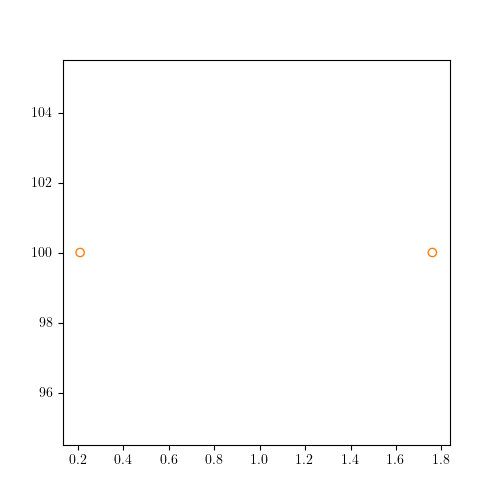

In [24]:
plt.figure(figsize=(5,5))
for i, key in enumerate(["RB", "FS", "MCTS", "IP"]):
    results = results_all[key]
    total = [r["total"] for r in results if r["total"] > 99]
    time = [r["time"] for r in results if r["total"] > 99]
    plt.scatter(time, total, label=key, marker="o", facecolor="None", edgecolor=util.TABLEAU_COLORS[i])
plt.xlabel("Time [s]")
plt.ylabel("Total [\\%]")
plt.xlim([0, 2])
plt.legend()
plt.show()